In [ ]:
using LinearAlgebra
using QuantumToolbox
using GLMakie
using Plots
using CairoMakie

# Main Functions

In [221]:
const Sub_divisions = 64
const iterations = 1024
const time = 400
const tolerance = 0.998
const step_size = 5

initial_state = ComplexF64[1;0]
H_Gate = ComplexF64[1/√2 1/√2; 1/√2 -1/√2]
T_gate = ComplexF64[1 0; 0 exp(im*π/Sub_divisions)]

function apply_gate(state, gate)
    return gate * state
end

function rotate(state, t)
    return T_gate ^ t * state
end

function measure(vec)
    if abs2(vec[1]) > rand()
        vec[1] = 1
        vec[2] = 0
        return 0
        end
    vec[1] = 0
    vec[2] = 1
    return 1
end

function ramsey(state, gate, t)
    prep = apply_gate(state, gate)
    spinning = rotate(prep, t)
    final = apply_gate(spinning, gate)
    return measure(final)
end

function count(n, state, gate, t)
    count = 0
    for i in range(1,n)
        measured = ramsey(state, gate, t)
        if measured < 1
            count += 1
        end
    end
    return count
end

function operate()
    t_range = range(1, time)
    data = []
    for i in t_range
        push!(data, count(iterations, initial_state, H_Gate, i))
    end
    return data
end


function convert_to_prob(lst)
    prob = []
    for i in range(1,length(lst))
        push!(prob, lst[i]/iterations)
    end
    return prob
end

convert_to_prob (generic function with 1 method)

# Plotting the Ramsey Experiment 

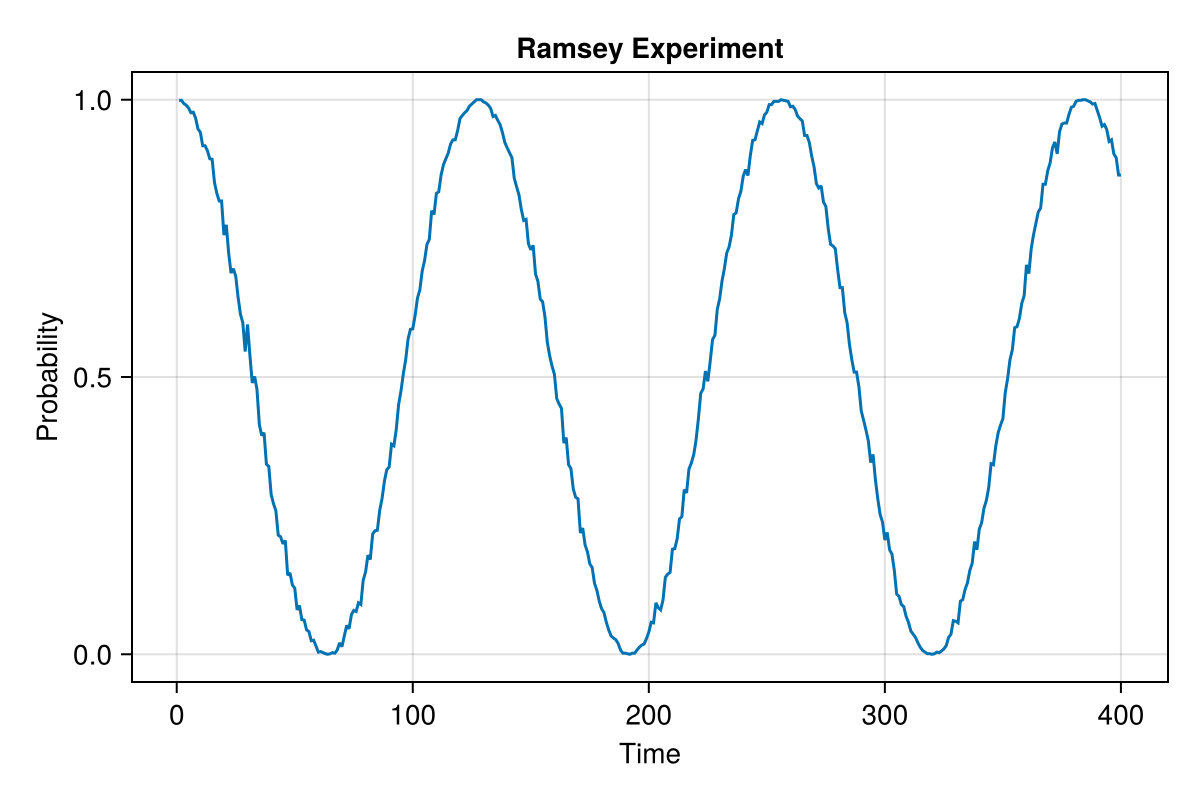

CairoMakie.Screen{IMAGE}


In [222]:
probs = convert_to_prob(operate())

fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time", ylabel = "Probability")
lines!(ax, probs)
display(fig)


# Calculating Period

In [ ]:
function calculate_ramsey_frequency(lst)
    period = []
    for i in range(1,length(lst); step = step_size)
        if lst[i]>tolerance
            push!(period, i)
        end
    end
    return (period[length(period)] - period[1])/length(period)
end


function max_period()
    periods = []
    for i in range(1,10)
        push!(periods, calculate_ramsey_frequency(convert_to_prob(operate())))
    end
    return [periods, maximum(periods), sum(periods)/length(periods)]
end

max_period (generic function with 1 method)

# Description
1) Start with the ground state |0>
2) Apply a π/2 rotation around the x axis(also the Hadamard Gate) which create the |+>
3) Apply a T rotation gate of a small amount to simulate the vecotr precessing around the XY plane
4) After performing the T gate for some number of iteration, reapply the π/2 gate 
    - For the majority of cases, this will lead to the state being somewhere on the Bloch sphere that isn't clean
5) Measure the state, count wether it goes to |0> or |1>, repeat the measurement 1024 times
6) Convert the measurement to a probability and plot the probability for a range of times

